In [1]:
import os
import sys
import subprocess
import numpy as np
from IPython.display import Image, display


In [2]:
lib_dir = os.getcwd()
if "notebooks" in lib_dir:
    lib_dir = os.path.join(lib_dir[:-10], 'PROFET')
elif lib_dir == "/content":
    lib_dir = lib_dir + "/GPA-source_code"
os.chdir(lib_dir)
print(lib_dir)

main_dir = os.path.dirname(lib_dir)
sys.path.insert(0, main_dir)  # for util.utils
sys.path.insert(0, lib_dir)   # for models.velocityfield
data_dir = os.path.join(main_dir, 'data', '')

os.makedirs(os.path.join(main_dir, 'data'), exist_ok=True)
os.makedirs(os.path.join(main_dir, 'assets'), exist_ok=True)

from util.utils import (
    ResourceMonitor,
    reduce_dimension, save_preprocessed_data, load_preprocessed_data, visualize_data,
    generate_animation, generate_W2distance_plot,
)

from util.utils import ResourceMonitor, load_preprocessed_data, generate_animation, generate_W2distance_plot

contrast_colors = {
    0: '#1f77b4',  # blue
    1: '#ff7f0e',  # orange
    2: '#d62728',  # red 
    3: '#8c564b',  # brown
    4: '#9467bd',  # purple
    8:  '#2ca02c'  # green (to be used for index 8) 
}

/Users/hyemin/Documents/source_code/ongoing/Trajectory-Inference/PROFET/PROFET
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : OpenMP library not found, it must be downloaded through Homebrew for apple Silicon chips
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


## Axolotl dataset

### Data property

* 5 snapshots at day 0, 1, 2, 3, 4
* 2,000 genes · 18,648 total cells
* Training timepoints: `times=[0, 2, 4]`, `d_red=2`
* Cells per training tp: Day 0: 3,831 · Day 2: 2,563 · Day 4: 5,185
* Held-out / Intermediate: Day 1: 3,177 · Day 3: 3,892

### Data structure

Raw files are loaded from the data directory:

* `Axolotl_data/gene_expression_Axolotl_2000_and_epi_selected.txt` : gene expression matrix (cells × genes)
* `Axolotl_data/filtered_metadata_Axolotl_selected.txt` : cell metadata including day labels

In [9]:
# Preprocessing function
def load_Axolotl_dataset():
    import pandas as pd

    # gene_expression dataset => full_matrix
    GE_matrix_file = data_dir + 'Axolotl_data/gene_expression_Axolotl_2000_and_epi_selected.txt'
    if os.path.exists(GE_matrix_file):
        df = pd.read_table(GE_matrix_file, sep="\t")
        print(df)
        full_matrix = np.array(df)[:,1:]
    else:
        print("If full gene expression matrix is stored in the directory, load and view it.")

    # time information => time_label
    time_info_file = data_dir + 'Axolotl_data/filtered_metadata_Axolotl_selected.txt'
    df_cls = pd.read_table(time_info_file, sep="\t")
    time_label = np.array(df_cls['day'])
    print("classes:", set(time_label))
        
    return full_matrix, time_label

                                       id  0610010F05RIK  1110037F02RIK  \
0      Axolotl_control.AAACCTGAGATGCGAC.1            0.0       2.293510   
1      Axolotl_control.AAACCTGCAAGTAGTA.1            0.0       0.000000   
2      Axolotl_control.AAACCTGGTTAAGAAC.1            0.0       0.000000   
3      Axolotl_control.AAACCTGGTTGATTGC.1            0.0       0.000000   
4      Axolotl_control.AAACCTGTCCACGACG.1            0.0       0.000000   
...                                   ...            ...            ...   
18643    Axolotl_22dpa.TTTGTCAGTCGGCATC.1            0.0       0.000000   
18644    Axolotl_22dpa.TTTGTCAGTCTAGGTT.1            0.0       0.000000   
18645    Axolotl_22dpa.TTTGTCATCACGCATA.1            0.0       0.000000   
18646    Axolotl_22dpa.TTTGTCATCATATCGG.1            0.0       1.757766   
18647    Axolotl_22dpa.TTTGTCATCCGTACAA.1            0.0       0.000000   

       1190002N15RIK  1700037H04RIK  2510009E07RIK  4930402H24RIK  \
0           0.000000       0.0

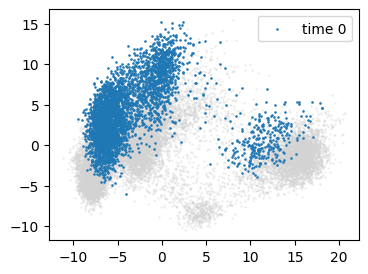

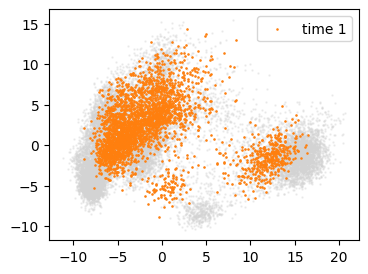

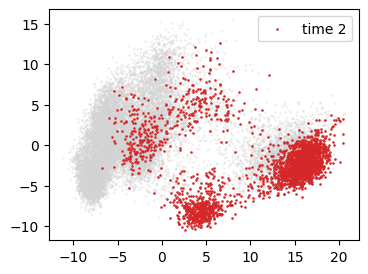

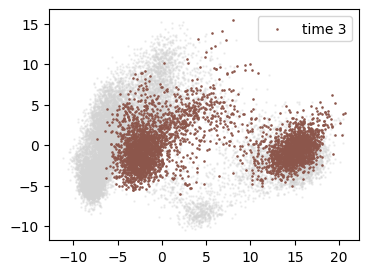

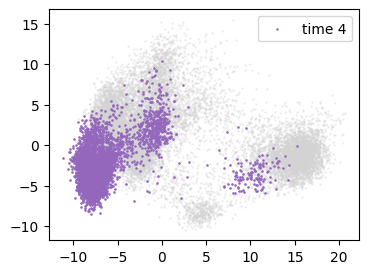

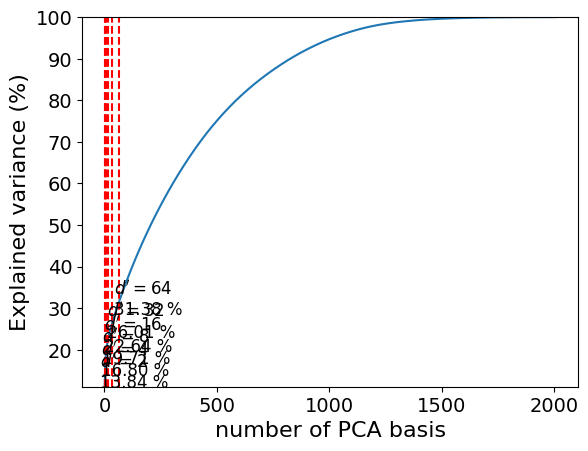

In [10]:
# Data preprocess
example_name = 'Axolotl_data_2000' # 
d_reds = [2, 4, 8, 16,32, 64] # [] or list of reduced dimensions
    
full_matrix, time_label = load_Axolotl_dataset()
visualize_data(full_matrix, time_label, colors=contrast_colors)
try:
    pca, projected_matrix = reduce_dimension(full_matrix, d_reds, example_name)
    data = {'full_matrix': full_matrix, 'time_label': time_label, 'pca': pca, 'projected_matrix': projected_matrix}
except:
    data = {'full_matrix': full_matrix, 'time_label': time_label}
save_preprocessed_data(data, example_name)

In [11]:
from collections import Counter
cnt = Counter(time_label)

In [12]:
# Load precomputed preprocessed data
try:
    time_label, full_matrix, projected_matrix, pca = load_preprocessed_data(example_name)
except:
    time_label, full_matrix = load_preprocessed_data(example_name)

time_points = sorted(list(set(time_label)))

## PROFET

In [ ]:
# PROFET step 1: GPA
d_red = 2 #16
times = [0, 2, 4]
dimension_reduction = 'Y'
exp_no = "test"
exp_memo = f"dim{d_red}_{exp_no}"

result_dir = os.path.join(main_dir, "assets", example_name, exp_memo)
os.makedirs(result_dir, exist_ok=True)

# tunable parameters
adjust_lr_P_epochs = 'Y'    # 'Y' to auto-adjust lr_P and epochs w.r.t. dimensionality
                            # 'N' to use specified lr_P and epochs below
lr_P = 0.0025
epochs = 5000
specify_f_Lip_threshold = 'Y'    # 'Y' to stop when f_Lip divergence < threshold
f_Lip_threshold = 1e-4

In [ ]:
os.chdir(lib_dir)

dimension_note = f'dim{d_red}-' if dimension_reduction in ['Y', 'yes'] else ''

with ResourceMonitor() as monitor:
    for i in range(len(times) - 1):
        cmd = (
            f"python3 run_GPA.py"
            f" --dataset {example_name}"
            f" --label {times[i]} {times[i+1]}"
            f" --N_dim {d_red}"
            f" --exp_no {exp_no}"
            f" --dimension_reduction {dimension_reduction}"
        )
        if adjust_lr_P_epochs in ['N', 'no']:
            cmd += f" --adjust_lr_P_epochs {adjust_lr_P_epochs} -lr_P {lr_P} --epochs {epochs}"
        if specify_f_Lip_threshold in ['Y', 'yes']:
            cmd += f" --f_Lip_threshold {f_Lip_threshold}"
        subprocess.run(cmd, shell=True, check=True)

monitor.report("PROFET GPA", dataset=example_name, d_red=d_red,
               filename=os.path.join(result_dir, "resources.txt"))

In [ ]:
# PROFET step 2: Force-Matching for two consecutive intervals

if dimension_reduction in ['Y', 'yes']:
    dimension_note = f'dim{d_red}-'
else:
    dimension_note = ''

# Define the two ForceMatching runs
force_matching_runs = [
    {
        "pair_times": [times[0], times[1]],
        "intermediate_times": [1],
        "exp_memo": f"{exp_memo}_t{times[0]}_t{times[1]}_inter1"
    },
    {
        "pair_times": [times[1], times[2]],
        "intermediate_times": [3],
        "exp_memo": f"{exp_memo}_t{times[1]}_t{times[2]}_inter3"
    }
]

os.chdir(lib_dir)

for run in force_matching_runs:
    
    pair_times = run["pair_times"]
    intermediate_times = run["intermediate_times"]
    exp_memo_run = run["exp_memo"]
    
    gpa_filenames = [
        f'KL-Lipschitz_1.0000-{pair_times[0]}_{pair_times[1]}times-'
        f'{dimension_note}{cnt[pair_times[1]]:04d}_{cnt[pair_times[0]]:04d}-00-{exp_no}.pickle'
    ]
    
    gpa_filenames_join = " ".join(gpa_filenames)
    times_join = " ".join([str(t) for t in pair_times])
    intermediate_times_join = " ".join([str(t) for t in intermediate_times])
    
    cmd = (
        f"python3 run_ForceMatching.py"
        f" --dataset {example_name}"
        f" --ts {times_join}"
        f" --intermediate_times {intermediate_times_join}"
        f" --exp_memo {exp_memo_run}"
        f" --files {gpa_filenames_join}"
    )
    
    print(f"\nRunning ForceMatching for times {pair_times} with intermediate_times {intermediate_times}")
    print(cmd)
    
    with ResourceMonitor() as monitor:
        subprocess.run(cmd, shell=True, check=True)
    
    monitor.report(
        f"PROFET ForceMatching t{pair_times[0]}_t{pair_times[1]}",
        dataset=example_name,
        d_red=d_red,
        filename=os.path.join(
            result_dir,
            f"resources_ForceMatching_t{pair_times[0]}_t{pair_times[1]}.txt"
        )
    )

In [ ]:
# -------------------------------------------------------
# Load two velocity fields and integrate ODE piecewise
# -------------------------------------------------------
from models.velocityfield import VelocityField
import os
import numpy as np

# -------------------------------------------------------
# Folder names generated from your ForceMatching step
# -------------------------------------------------------
exp_memo_1 = f"dim{d_red}_test_t{times[0]}_t{times[1]}_inter1"
exp_memo_2 = f"dim{d_red}_test_t{times[1]}_t{times[2]}_inter3"

exp_memos = [exp_memo_1, exp_memo_2]

velocity_nets = []
params = []
dts = []
Ts = []

# -------------------------------------------------------
# Load velocity fields
# -------------------------------------------------------
for exp_memo_piece in exp_memos:
    
    save_dir = os.path.join(
        main_dir,
        'assets',
        example_name,
        exp_memo_piece,
        ''
    )
    
    print(f"Loading velocity field from: {save_dir}")
    
    velocity_net, p = VelocityField.load(save_dir)
    
    dt = p['numerical_ts'][-1] / 200
    T = p['numerical_ts'][-1]
    physical_dt  = dt * p['ts'][-1] / p['numerical_ts'][-1]
    
    velocity_nets.append(velocity_net)
    params.append(p)
    dts.append(dt)
    Ts.append(T)

# -------------------------------------------------------
# Initial input data at the first time point
# -------------------------------------------------------
if dimension_reduction in ['N', 'no']:
    input_data = full_matrix[time_label == times[0], :]
else:
    input_data = projected_matrix[time_label == times[0], :d_red]

# -------------------------------------------------------
# Piecewise integration
# -------------------------------------------------------
X1_trpts_all = []
X1_trpts_pieces = []

current_data = input_data.copy()

for i, velocity_net in enumerate(velocity_nets):
    
    print(f"Integrating piece {i + 1}: time {times[i]} to {times[i + 1]}")
    
    X1_trpts_piece = velocity_net.integrate(
        current_data,
        T=Ts[i],
        dt=dts[i]
    )
    
    # Save each individual piece
    X1_trpts_pieces.append(X1_trpts_piece)
    
    # Save combined trajectory without duplicating the connection frame
    if i == 0:
        X1_trpts_all.extend(X1_trpts_piece)
    else:
        X1_trpts_all.extend(X1_trpts_piece[1:])
    
    # Use final state of this piece as input for the next piece
    current_data = X1_trpts_piece[-1]

print(
    f"Combined trajectory frames: {len(X1_trpts_all)}, "
    f"shape per frame: {X1_trpts_all[0].shape}"
)

# -------------------------------------------------------
# Save combined piecewise trajectory
# -------------------------------------------------------
traj_npy = os.path.join(result_dir, 'piecewise_trajectories.npy')
np.save(traj_npy, np.stack(X1_trpts_all, axis=0))

print(f"Saved combined piecewise trajectory to {traj_npy}")

# -------------------------------------------------------
# Save each trajectory piece separately
# -------------------------------------------------------
for i, X1_trpts_piece in enumerate(X1_trpts_pieces):
    
    piece_traj_npy = os.path.join(
        result_dir,
        f'piece{i + 1}_trajectories_t{times[i]}_t{times[i + 1]}.npy'
    )
    
    np.save(piece_traj_npy, np.stack(X1_trpts_piece, axis=0))
    
    print(f"Saved piece {i + 1} trajectory to {piece_traj_npy}")

In [ ]:
# -------------------------------------------------------
# Generate animations and W2 plots for each piece
# -------------------------------------------------------

piece_configs = [
    {
        "name": "piece1",
        "times": [times[0], times[1]],
        "intermediate_times": [1],
        "X1_trpts": X1_trpts_pieces[0],
    },
    {
        "name": "piece2",
        "times": [times[1], times[2]],
        "intermediate_times": [3],
        "X1_trpts": X1_trpts_pieces[1],
    }
]

for cfg in piece_configs:
    
    piece_name = cfg["name"]
    piece_times = cfg["times"]
    piece_intermediate_times = cfg["intermediate_times"]
    X1_trpts_piece = cfg["X1_trpts"]
    
    img_src1 = os.path.join(result_dir, f'{piece_name}_movie-particles.gif')
    img_src2 = os.path.join(result_dir, f'{piece_name}_movie-velocities.gif')
    img_src3 = os.path.join(result_dir, f'{piece_name}_w2distances.png')
    
    print(f"\nGenerating outputs for {piece_name}: times {piece_times}")
    
    generate_animation(
        example_name,
        piece_times,
        piece_intermediate_times,
        X1_trpts_piece,
        img_src1,
        d_red,
        True,
        colors=contrast_colors,
        plot_vectorfield=False
    )
    display(Image(filename=img_src1))
    
    generate_animation(
        example_name,
        piece_times,
        piece_intermediate_times,
        X1_trpts_piece,
        img_src2,
        d_red,
        True,
        colors=contrast_colors,
        plot_vectorfield=True
    )
    display(Image(filename=img_src2))
    
    generate_W2distance_plot(
        example_name,
        piece_times,
        piece_intermediate_times,
        X1_trpts_piece,
        img_src3,
        d_red,
        True,
        colors=contrast_colors
    )
    display(Image(filename=img_src3))

## Downstream Analysis — Trajectory Visualization and Subtrajectory Classification

Visualizes full reconstructed trajectories and classifies them into subtrajectories based on **ancestral cell state** (source clustering) for the Axolotl dataset.

**Prerequisites:**
- PROFET section above must have been run so that `X1_trpts`, `p`, `physical_dt`, `full_matrix`, `time_label`, `time_points`, `projected_matrix`, and `pca` are in scope.
- The cluster labels (`{exp_memo}_X2_hat_clusters.csv`) generated here are required by the Gene Expression Dynamics section below.

In [ ]:
import pandas as pd
from sklearn import decomposition
from util.downstream import (
    generate_static_trajectory_plots_two_timepoints,
    classify_X2_hat,
    generate_static_cluster_plot_source,
)

# d_red-component PCA for trajectory visualization and inverse_transform
pca_d = decomposition.PCA(n_components=d_red, random_state=0)
pca_d.fit(full_matrix)

# Per-timepoint full expression matrices
mats = {t: full_matrix[time_label == t].astype(float) for t in time_points}

source_t, target_t = times[0], times[-1]  # 0, 4
optimal_k = 2   # number of subtrajectory classes; adjust based on biology
start_i = 0
index = 10

### Static Trajectory Visualization

Generates static scatter plots of the full reconstructed trajectory: one with trajectory snapshots (coloured by time via viridis gradient) and one showing only the training/test data snapshots.

In [ ]:
# -------------------------------------------------------
# Generate static trajectory plots for each piece
# -------------------------------------------------------

piece_configs = [
    {
        "name": "piece1",
        "times": [times[0], times[1]],
        "intermediate_times": [1],
        "X1_trpts": X1_trpts_pieces[0],
        "exp_memo": exp_memo_1,
    },
    {
        "name": "piece2",
        "times": [times[1], times[2]],
        "intermediate_times": [3],
        "X1_trpts": X1_trpts_pieces[1],
        "exp_memo": exp_memo_2,
    }
]

for cfg in piece_configs:
    
    piece_name = cfg["name"]
    piece_times = cfg["times"]
    piece_intermediate_times = cfg["intermediate_times"]
    X1_trpts_piece = cfg["X1_trpts"]
    exp_memo_piece = cfg["exp_memo"]
    
    output_with = os.path.join(
        result_dir,
        f"{exp_memo_piece}_static_trajectory_with_snapshots.png"
    )
    
    output_without = os.path.join(
        result_dir,
        f"{exp_memo_piece}_static_trajectory_without_snapshots.png"
    )
    
    print(f"\nGenerating static trajectory plots for {piece_name}: {piece_times}")
    
    generate_static_trajectory_plots_two_timepoints(
        pca=pca_d,
        physical_dt=physical_dt,
        days=piece_times,
        intermediate_days=piece_intermediate_times,
        X1_trpts=X1_trpts_piece,
        mats=mats,
        d_red=d_red,
        output_file_with_snapshots=output_with,
        output_file_without_snapshots=output_without,
    )
    
    display(Image(filename=output_with))
    display(Image(filename=output_without))

## Downstream Analysis — Fate Analysis

Classifies reconstructed trajectories by terminal fate cluster and visualises fate-specific subtrajectories for the Axolotl dataset.

**Prerequisites:**
- PROFET section above must have been run so that `X1_trpts_pieces`, `pca_d`, `mats`, and `time_points` are in scope.
- Metadata with cluster labels (`filtered_metadata_Axolotl_selected_with_cluster.txt`) must be available in the data directory.

In [ ]:
# Import downstream analysis functions
from util.downstream import (
    generate_W2distance_plot,
    generate_static_cluster_plot_target_with_dfcluster_selected_clusters,
)

### Load data

In [ ]:
import os
import pandas as pd

cls_path = os.path.join(data_dir, 'Axolotl_data', 'filtered_metadata_Axolotl_selected_with_cluster.txt')
df_cluster = pd.read_table(cls_path, sep="\t")

# drop any accidental unnamed columns
df_cluster

In [ ]:
import pandas as pd

def canonicalize_cnv_labels(arr_like):
    s = pd.Series(arr_like)
    def _canon(x):
        if pd.isna(x): return "NA"
        try: return f"{int(x)}"
        except Exception: return f"{str(x)}"
    return s.map(_canon).values

def make_cnv_lut(all_labels, palette=None):
    if palette is None:
        palette = ("teal","magenta","orange","navy","gold","lime","crimson","slategray",
                   "purple","brown","cyan","olive","coral","indigo","tomato",
                   "darkorange","steelblue","goldenrod","seagreen","orchid","gray")
    canon = canonicalize_cnv_labels(all_labels)       # <-- canonicalize first
    uniq_all = sorted(pd.Series(canon).unique(), key=lambda x: (str(type(x)), x))
    return {lab: palette[i % len(palette)] for i, lab in enumerate(uniq_all)}


meta_path = data_dir + 'Axolotl_data/filtered_metadata_Axolotl_selected_with_cluster.txt'
meta_full = pd.read_table(meta_path, sep="\t")

# Use raw cnv values; the function will canonicalize to "clone X"/"NA"
global_cnv_lut = make_cnv_lut(meta_full['cluster'])


### Generate Axolotl subtrajectories by terminal fate

Extracts fate-specific subtrajectories by clustering cells at the target time point. Saves cluster labels for each source cell and generates a coloured trajectory plot highlighting each terminal fate.

In [ ]:
result_dir = '%s/assets/%s/' % (main_dir, example_name)


folder_name = 'Axolotl_data_2000' # mESC data pickle file name


exp_memo = folder_name
output_file_cluster_plot_target =  f"{result_dir}{folder_name}_static_cluster_plot_target.png"

optimal_k = 3


source_t, target_t = 0, 2
intermediate_t = []

start_i = 0
index = 1


X1_hat_labels = generate_static_cluster_plot_target_with_dfcluster_selected_clusters(
    pca_d,
    source_t, target_t, X1_trpts_pieces[0], mats, optimal_k, start_i, index, p,
    df_cluster,
    day_value=2,
    day_col='day', cluster_col='cluster',
    reverse=False, intermediate_t=intermediate_t,
    d_red=2, random_state=42, exp_memo=exp_memo, output_file=output_file_cluster_plot_target,
    selected_clusters=None,
    hide_unselected=False,
    bg_alpha=0.15, traj_alpha=0.9, traj_gray_alpha=0.15,
    point_size=3, line_alpha=0.5, line_width=0.6,
    cnv_lut=global_cnv_lut,     # now contains 'BE'
    strict_colors=True,
    color_mode='final'
)

# Convert the labels into a DataFrame for saving
df_clusters = pd.DataFrame({
    "Cell_Index": np.arange(len(X1_hat_labels)),  # Assuming each cell has an index
    "Cluster_Label": X1_hat_labels
})

# Define the filename
cluster_save_path = f"{result_dir}{exp_memo}_X1_hat_clusters.csv"

# Save as CSV
df_clusters.to_csv(cluster_save_path, index=False)
print(f"Cluster labels saved to {cluster_save_path}")

# Return the saved filename for future use
cluster_save_path